In [3]:

import os
import numpy as np
from tqdm import tqdm
import pandas as pd

import time
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation,Dropout,Conv2D, MaxPooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import kagglehub


# Download latest version
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define directory paths
train_dir = 'CTP-Final/train'
test_dir = 'CTP-Final/test'

# Define image size and batch size
IMG_HEIGHT, IMG_WIDTH = 48, 48
BATCH_SIZE = 32

# Data Augmentation for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to 0-1
    rotation_range=20,            # Randomly rotate images by 20 degrees
    width_shift_range=0.2,        # Randomly shift images horizontally by 20%
    height_shift_range=0.2,       # Randomly shift images vertically by 20%
    shear_range=0.2,              # Shear transformation
    zoom_range=0.2,               # Randomly zoom in images
    horizontal_flip=True,         # Randomly flip images horizontally
    fill_mode='nearest'           # Fill in pixels with nearest values after transformations
)

# Only rescale for test data, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data with data augmentation
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'           # For binary classification (real vs fake)
)

# Load test data without augmentation
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
# Display the class names for the training and test generators
print("Training classes:", train_generator.class_indices)
print("Test classes:", test_generator.class_indices)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Training classes: {'FAKE': 0, 'REAL': 1}
Test classes: {'FAKE': 0, 'REAL': 1}


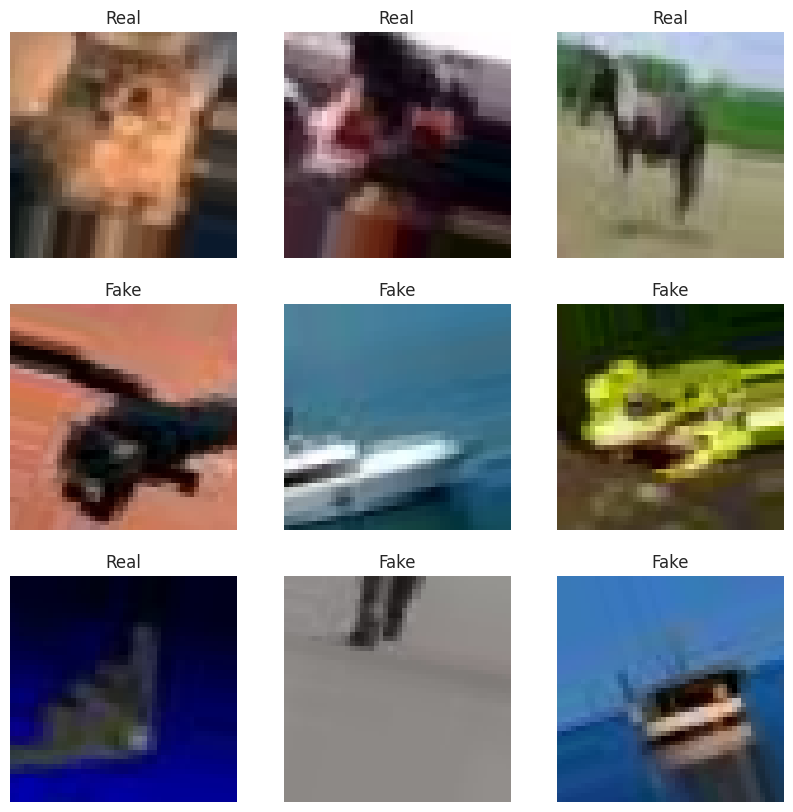

In [5]:
import matplotlib.pyplot as plt

# Get a batch of images and labels
images, labels = next(train_generator)

# Set up a grid to display images
plt.figure(figsize=(10, 10))
for i in range(9):  # Display the first 9 images
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Real" if labels[i] == 1 else "Fake")  # Assuming 1 = Real and 0 = Fake
    plt.axis('off')  # Hide axes for a cleaner display

plt.show()

In [6]:
import pandas as pd
import os
import tensorflow as tf

def load_and_preprocess_images(train_dir, img_size=(48 ,48)):
    # Initialize lists for storing image details
    image_names = []
    labels = []
    pixel_arrays = []

    # Loop through the directories to get image paths, labels, and pixel arrays
    for label in os.listdir(train_dir):
        label_dir = os.path.join(train_dir, label)
        if os.path.isdir(label_dir):
            for img_name in os.listdir(label_dir):
                img_path = os.path.join(label_dir, img_name)

                # Load and preprocess the image
                img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
                img_array = tf.keras.preprocessing.image.img_to_array(img)
                img_array = img_array / 255.0  # Normalize the pixel values

                # Append details to lists
                image_names.append(img_name)
                labels.append(label)
                pixel_arrays.append(img_array)

    # Create a DataFrame
    df = pd.DataFrame({
        'image_name': image_names,
        'label': labels,
        'pixel_array': pixel_arrays
    })

    return df

# Example usage
r'C:\Users\johnn\CTP\CTP\train'
df = load_and_preprocess_images(train_dir)


In [6]:
df.head()


,image_name,label,pixel_array
0,2596 (2).jpg,REAL,"[[[0.5411765, 0.49019608, 0.5176471], [0.56862..."
1,0579 (3).jpg,REAL,"[[[0.16470589, 0.13333334, 0.050980393], [0.18..."
2,4526 (7).jpg,REAL,"[[[0.6509804, 0.64705884, 0.46666667], [0.6588..."
3,2096.jpg,REAL,"[[[0.3254902, 0.41568628, 0.5411765], [0.32549..."
4,2342 (5).jpg,REAL,"[[[0.09803922, 0.09019608, 0.13333334], [0.043..."


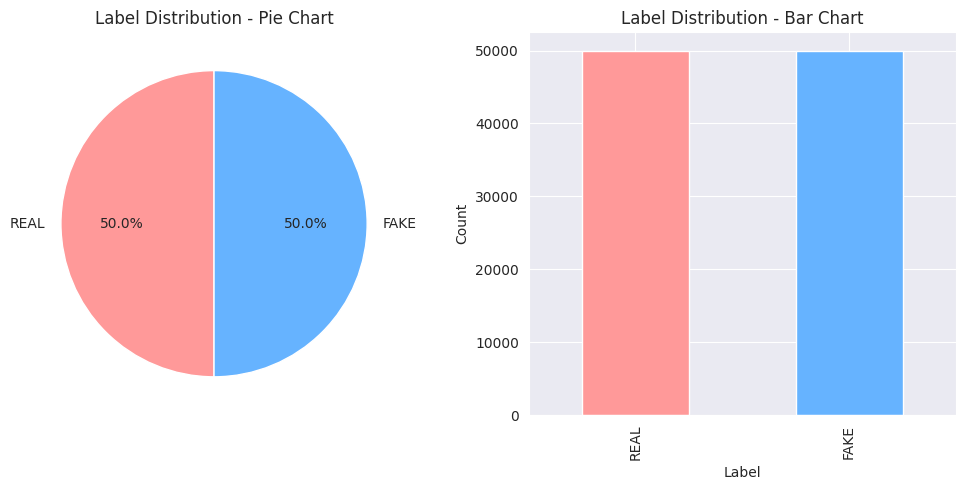

In [7]:
# Count the occurrences of each label
label_counts = df['label'].value_counts()

# Plot a pie chart
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
label_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Label Distribution - Pie Chart')
plt.ylabel('')

# Plot a bar chart
plt.subplot(1, 2, 2)
label_counts.plot.bar(color=['#ff9999','#66b3ff'])
plt.title('Label Distribution - Bar Chart')
plt.xlabel('Label')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [8]:
print("Null counter: ",df.isnull().sum())
print("Shape of the dataframe: ",df.shape)


Null counter:  image_name     0
label          0
pixel_array    0
dtype: int64
Shape of the dataframe:  (100000, 3)


In [9]:
#Same thing for the test data

import pandas as pd
import os
import tensorflow as tf

def load_and_preprocess_images(train_dir, img_size=(48, 48)):
    # Initialize lists for storing image details
    image_names = []
    labels = []
    pixel_arrays = []

    # Loop through the directories to get image paths, labels, and pixel arrays
    for label in os.listdir(train_dir):
        label_dir = os.path.join(train_dir, label)
        if os.path.isdir(label_dir):
            for img_name in os.listdir(label_dir):
                img_path = os.path.join(label_dir, img_name)

                # Load and preprocess the image
                img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
                img_array = tf.keras.preprocessing.image.img_to_array(img)
                img_array = img_array / 255.0  # Normalize the pixel values

                # Append details to lists
                image_names.append(img_name)
                labels.append(label)
                pixel_arrays.append(img_array)

    # Create a DataFrame
    df = pd.DataFrame({
        'image_name': image_names,
        'label': labels,
        'pixel_array': pixel_arrays
    })

    return df

# Example usage
r'C:\Users\johnn\CTP\CTP\train'
df_test= load_and_preprocess_images(test_dir)


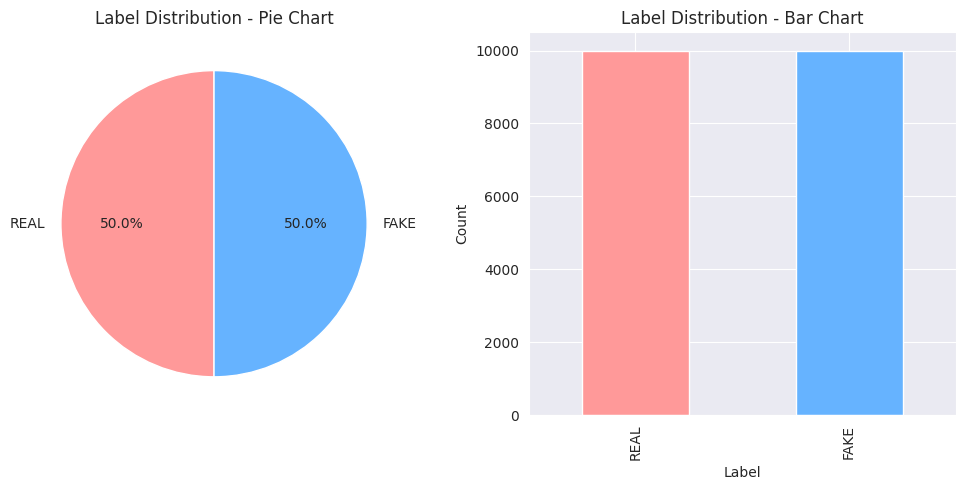

In [10]:
# Count the occurrences of each label
label_counts = df_test['label'].value_counts()

# Plot a pie chart
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
label_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Label Distribution - Pie Chart')
plt.ylabel('')

# Plot a bar chart
plt.subplot(1, 2, 2)
label_counts.plot.bar(color=['#ff9999','#66b3ff'])
plt.title('Label Distribution - Bar Chart')
plt.xlabel('Label')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [11]:
X = df['pixel_array']

X

,pixel_array
0,"[[[0.5411765, 0.49019608, 0.5176471], [0.56862..."
1,"[[[0.16470589, 0.13333334, 0.050980393], [0.18..."
2,"[[[0.6509804, 0.64705884, 0.46666667], [0.6588..."
3,"[[[0.3254902, 0.41568628, 0.5411765], [0.32549..."
4,"[[[0.09803922, 0.09019608, 0.13333334], [0.043..."
...,...
99995,"[[[0.41568628, 0.5686275, 0.7372549], [0.41568..."
99996,"[[[0.4509804, 0.60784316, 0.84705883], [0.4509..."
99997,"[[[0.28235295, 0.54901963, 0.21568628], [0.364..."
99998,"[[[0.20392157, 0.15686275, 0.17254902], [0.211..."


In [12]:
y = df['label']

y

,label
0,REAL
1,REAL
2,REAL
3,REAL
4,REAL
...,...
99995,FAKE
99996,FAKE
99997,FAKE
99998,FAKE


In [13]:

oversampler = RandomOverSampler(sampling_strategy="auto")

X, y = oversampler.fit_resample(X.values.reshape(-1,1), y)

In [14]:
X

array([[array([[[0.5411765 , 0.49019608, 0.5176471 ],
                [0.5686275 , 0.52156866, 0.5372549 ],
                [0.5686275 , 0.52156866, 0.5372549 ],
                ...,
                [0.7490196 , 0.6627451 , 0.60784316],
                [0.72156864, 0.6313726 , 0.5686275 ],
                [0.72156864, 0.6313726 , 0.5686275 ]],

               [[0.52156866, 0.4627451 , 0.48235294],
                [0.5254902 , 0.47843137, 0.49411765],
                [0.5254902 , 0.47843137, 0.49411765],
                ...,
                [0.79607844, 0.7058824 , 0.6509804 ],
                [0.7764706 , 0.6745098 , 0.60784316],
                [0.7764706 , 0.6745098 , 0.60784316]],

               [[0.52156866, 0.4627451 , 0.48235294],
                [0.5254902 , 0.47843137, 0.49411765],
                [0.5254902 , 0.47843137, 0.49411765],
                ...,
                [0.79607844, 0.7058824 , 0.6509804 ],
                [0.7764706 , 0.6745098 , 0.60784316],
               

In [15]:
y

,label
0,REAL
1,REAL
2,REAL
3,REAL
4,REAL
...,...
99995,FAKE
99996,FAKE
99997,FAKE
99998,FAKE


In [16]:
print("X.shape =", X.shape)

print("y.shape =", y.shape)

X.shape = (100000, 1)
y.shape = (100000,)


In [14]:
X = pd.Series(X.flatten())

X


,0
0,"[[[0.5411765, 0.49019608, 0.5176471], [0.56862..."
1,"[[[0.16470589, 0.13333334, 0.050980393], [0.18..."
2,"[[[0.6509804, 0.64705884, 0.46666667], [0.6588..."
3,"[[[0.3254902, 0.41568628, 0.5411765], [0.32549..."
4,"[[[0.09803922, 0.09019608, 0.13333334], [0.043..."
...,...
99995,"[[[0.41568628, 0.5686275, 0.7372549], [0.41568..."
99996,"[[[0.4509804, 0.60784316, 0.84705883], [0.4509..."
99997,"[[[0.28235295, 0.54901963, 0.21568628], [0.364..."
99998,"[[[0.20392157, 0.15686275, 0.17254902], [0.211..."


In [15]:
import numpy as np

# Assuming X is a list or Series with each element as a 3D array for a single RGB image
X = np.array(X.tolist())  # Convert to numpy array if X is in another format

# Check if the shape is compatible with reshaping
if X.shape[1:] == (48, 48, 3):  # Each image is 48x48 pixels with 3 channels (RGB)
    X = X.reshape(-1, 48, 48, 3)
    print("Final shape of X:", X.shape)
else:
    print("Error: X entries do not match the expected shape for 48x48 RGB images.")


Final shape of X: (100000, 48, 48, 3)


In [19]:
print(X.shape)
print(y.shape)

(100000, 48, 48, 3)
(100000,)


In [16]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 48, 48, 3)
(20000, 48, 48, 3)
(80000,)
(20000,)


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the model
model = Sequential()

# Add convolutional layers
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

# Flatten the output and add dense layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # Binary classification (0 or 1)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 46, 46, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 21, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Map labels to binary format
y_test = np.where(y_test == 'REAL', 1, 0)
y_train = np.where(y_train == 'REAL', 1, 0)



In [19]:
from tensorflow.keras.callbacks import EarlyStopping     # Stop training when a monitored metric has stopped improving.
from tensorflow.keras.callbacks import ReduceLROnPlateau  # Reduce learning rate when a metric has stopped improving.
early_stopping = EarlyStopping(monitor = "val_accuracy",
                               patience = 10,
                               mode = "auto",
                               restore_best_weights = True)



In [20]:
reduce_learning_rate = ReduceLROnPlateau(monitor ="val_accuracy",
                                         factor = 0.5,
                                         verbose = 1,
                                         min_lr = 0.00001)

In [ ]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test),   callbacks = [early_stopping, reduce_learning_rate])

In [ ]:
import os

# Get the current working directory
current_path = os.getcwd()
print("Current Kaggle working path:", current_path)


In [ ]:
import pickle

# Define the local file path where you want to save the history
file_path_history = r"c:\Users\johnn\CTP\CTP\trainHistoryDictionary.pkl"

# Save the history object
with open(file_path_history, "wb") as file:
    pickle.dump(history.history, file)

print("File saved at:", file_path_history)


In [27]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)

model_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(model_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step


ValueError: Classification metrics can't handle a mix of binary and continuous targets